# Run the complete election pipeline
Evaluate eight candidates across five outer elections, select by equal-weight mean accuracy, then retune, refit and evaluate 2024. Configure PostgreSQL and the tracking server first using docs/postgresql.md and docs/mlflow.md. The pipeline automatically reads .env.election. Source .mlflow/config.env before starting Jupyter for tracking settings. Rerun the setup cell below after updating the database code, including in an existing kernel.

Prepared CSVs, predictor guide, final predictions and confusion matrices remain in notebooks/outputs. Compact experiment histories are retained in MLflow.


In [3]:
import os
import importlib

# Use the local tracking server unless a server is already configured.
os.environ.setdefault("MLFLOW_TRACKING_URI", "http://127.0.0.1:5000")

from election import paths
from election.sql import apply_sql_queries

# Refresh database setup when this cell is rerun in an existing kernel.
importlib.reload(apply_sql_queries)
from election.pipeline.run_pipeline import run_pipeline

project_root = paths.project_root()

output_directory = project_root / "notebooks" / "outputs"
print(f"Saving pipeline outputs to: {output_directory}")


Saving pipeline outputs to: /workspaces/Election-Prediction-12.08/notebooks/outputs


In [4]:
selection = run_pipeline(output_dir=output_directory)
final_model = selection.model
report = selection.report
model_type = selection.model_name
import pandas as pd
display(report.scorecard())
display(pd.DataFrame(report.outer_results))
print(f"Selected model: {model_type}; status: {report.status}; execution: {report.execution_id}")
print("Final selected configuration:", report.final_fit)


/workspaces/Election-Prediction-12.08/.venv/lib/python3.14/site-packages/openpyxl/worksheet/header_footer.py:48: UserWarning: Cannot parse header or footer so it will be ignored
  warn("""Cannot parse header or footer so it will be ignored""")


🏃 View run Conditional XGBoost at: http://127.0.0.1:5000/#/experiments/67/runs/00c7900535e94ac0936d21287b3011fe
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/67
🏃 View run NN02: 64/32 validation-selected rate at: http://127.0.0.1:5000/#/experiments/67/runs/b219f685f023488bbb813cb10836c97c
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/67
🏃 View run NN03: 16 units fixed rate 0.3 at: http://127.0.0.1:5000/#/experiments/67/runs/2a51d5d3dd5548d383f5b516d28255e5
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/67
🏃 View run Random Forest at: http://127.0.0.1:5000/#/experiments/67/runs/234e639c80ec4af089b6d4ce2a0d3670
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/67
🏃 View run XGBoost Expanded at: http://127.0.0.1:5000/#/experiments/67/runs/f1a6a8b1d95c4cc4b47fc182c799471e
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/67
🏃 View run pipeline execution at: http://127.0.0.1:5000/#/experiments/67/runs/5b079e85164d4aabbffcd69956f8abce
🧪 View

ValueError: Set ELECTION_DATABASE_URL to the PostgreSQL election database; see docs/postgresql.md

## Final 2024 results
The pipeline has already evaluated and logged the final model. These cells display returned results and the saved confusion matrix.


accuracy                           0.745253
evaluation_rows                  632.000000
changed_seat_accuracy              0.486667
changed_seat_evaluation_rows     300.000000
retained_seat_accuracy             0.981873
retained_seat_evaluation_rows    331.000000
macro_f1                           0.488801
log_loss                           0.624894
previous_winner_accuracy           0.523734
previous_winner_known_rows       631.000000
seat_error_con                    97.000000
seat_error_lab                   -81.000000
seat_error_lib                   -38.000000
seat_error_natSW                  37.000000
seat_error_oth                   -15.000000
test_rows                        632.000000
excluded_rows                      0.000000
Name: 2024, dtype: float64

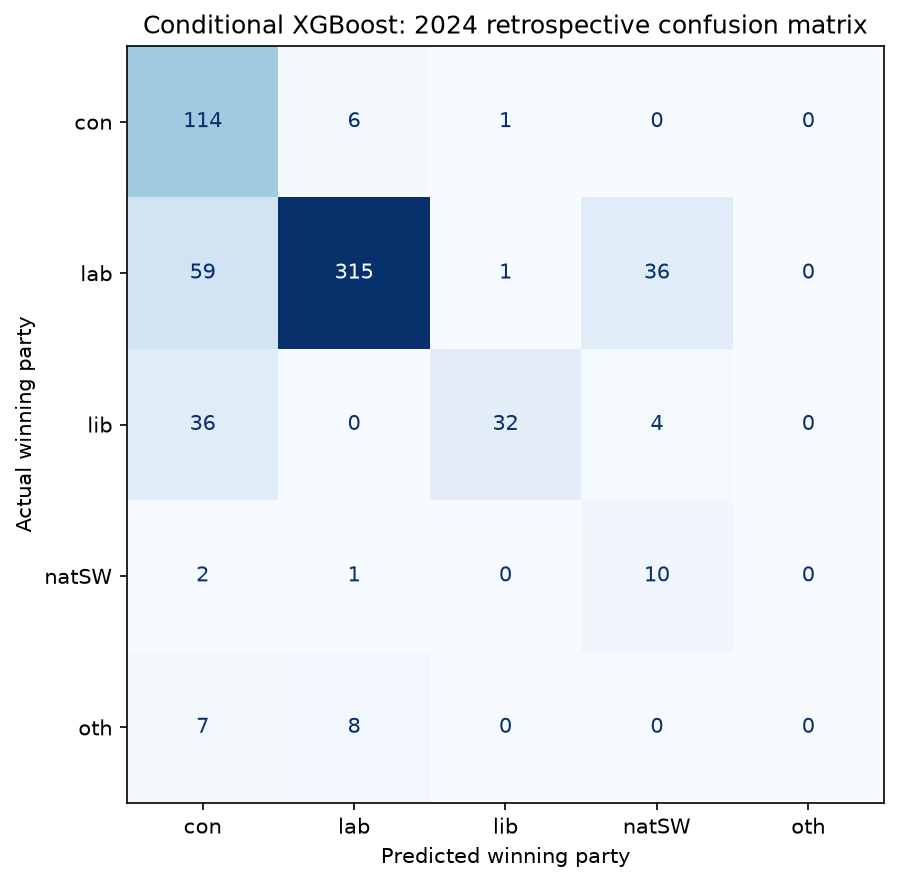

In [ ]:
display(pd.Series(report.final_metrics, name="2024"))
from IPython.display import Image, display
display(Image(filename=str(output_directory / "test_confusion_matrix.png")))
